In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , roc_auc_score , roc_curve , precision_recall_curve , auc



In [2]:
# Load the clusterd dataframe
df = pd.read_csv('Customer_Churn_clustered.csv')
df.head()


,CustomerTenure,TotalRevenue,OrderFrequency,TotalProductSubCategories,MostPurchasedCategory,AvgDaysBetweenOrders,RecencyRatio,ChurnLabel,Cluster,ClusterLabel
0,1105,9.017967,1.386294,6,1,417.0,0.499248,1,1,Loyal Customers
1,1109,8.761688,1.386294,7,1,530.0,0.088425,0,1,Loyal Customers
2,1117,9.001474,1.386294,3,1,389.0,0.626722,1,1,Loyal Customers
3,1126,9.004581,1.386294,5,1,431.0,0.476364,1,1,Loyal Customers
4,1101,9.011525,1.386294,4,1,414.0,0.505012,1,1,Loyal Customers


In [3]:
# Select the dependent and independent features from the dataframe.....as cluster label holds categorical values so we are not going to use it in the classification model
X = df.drop(['ChurnLabel','ClusterLabel','RecencyRatio','AvgDaysBetweenOrders','Cluster'],axis =1)
y = df['ChurnLabel']
X.shape , y.shape

((19119, 5), (19119,))

In [4]:
# Split the data into training and testing sets
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((14339, 5), (4780, 5), (14339,), (4780,))

In [5]:
# Train the model using Extreme Gradient Boosting (XGBoost)
model = XGBClassifier(
    max_depth=3,              # simpler trees
    learning_rate=0.05,
    n_estimators=250,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    reg_alpha=1,
    random_state=42
)
model.fit(X_train , y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
# Make predictions on the test dataset
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test , y_pred)
accuracy*100

89.97907949790796

In [7]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[2480,  109],
       [ 370, 1821]])

In [8]:
# now verify that the model is overfitted or not by checking the accuracy of the model on the training and testing dataset individually
accuracy_train = accuracy_score(y_train , model.predict(X_train))
accuracy_test = accuracy_score(y_test , model.predict(X_test))
accuracy_train*100 , accuracy_test*100

(90.3340539786596, 89.97907949790796)

In [9]:
# Generate the classification report 
report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2589
           1       0.94      0.83      0.88      2191

    accuracy                           0.90      4780
   macro avg       0.91      0.89      0.90      4780
weighted avg       0.90      0.90      0.90      4780



In [10]:
# Check the auc score of the model
y_proba = model.predict_proba(X_test)[:,1]
auc_score = roc_auc_score(y_test, y_proba)
auc_score

0.9724720973948167

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, make_scorer

auc = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(auc)
print("Mean AUC:", auc.mean())

[0.81505678 0.91289196 0.98663366 0.98015143 0.97427874]
Mean AUC: 0.9338025155815123


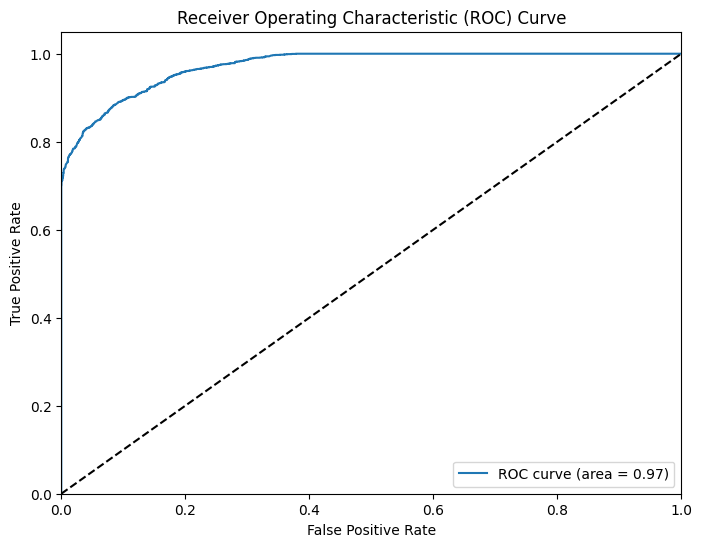

In [12]:
# Determine the model performance by plotting the ROC and AUC curves
fpr , tpr , thresholds = roc_curve(y_test , y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr , tpr , label = 'ROC curve (area = %0.2f)' % auc_score)
plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc = 'lower right')
plt.show()


In [17]:
# Choosing the optimal threshold point using Youden's J statistic
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])

# Youden's J = TPR - FPR (maximize this)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)
print("TPR at optimal:", tpr[optimal_idx])
print("FPR at optimal:", fpr[optimal_idx])

y_pred_optimal = (model.predict_proba(X_test)[:,1] >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal))
accuracy = accuracy_score(y_test, y_pred_optimal)
accuracy*100

Optimal Threshold: 0.45894367
TPR at optimal: 0.8831583751711547
FPR at optimal: 0.08420239474700657
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      2589
           1       0.90      0.88      0.89      2191

    accuracy                           0.90      4780
   macro avg       0.90      0.90      0.90      4780
weighted avg       0.90      0.90      0.90      4780



90.0836820083682

In [23]:
print("Accuracy:", accuracy_score(y_test, (y_proba >= 0.45)))
print("Threshold:", optimal_threshold)
print("Test size:", X_test.shape)

Accuracy: 0.8976987447698744
Threshold: 0.45894367
Test size: (4780, 5)


In [ ]:
# Find threshold where recall >= 0.90
for i in range(len(thresholds)):
    if tpr[i] >= 0.90:
        print("Threshold:", thresholds[i])
        break
    

Threshold: 0.44068304


In [14]:
cm = confusion_matrix(y_test, y_pred_optimal)
cm

array([[2371,  218],
       [ 256, 1935]])

In [15]:
# verigy the auc score at the optimal threshold
auc_score = roc_auc_score(y_test , y_pred_optimal)
auc_score*100

89.9477990212074

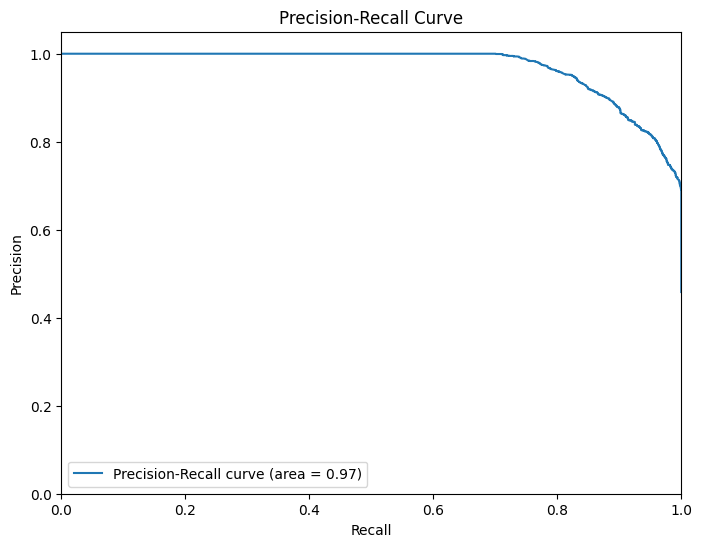

In [20]:
# Plot the precision-recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label='Precision-Recall curve (area = %0.2f)' % auc(recall, precision))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [ ]:
# Feature importance
model.feature_importances_

array([0.42547196, 0.03583706, 0.4366579 , 0.09320291, 0.00883017],
      dtype=float32)

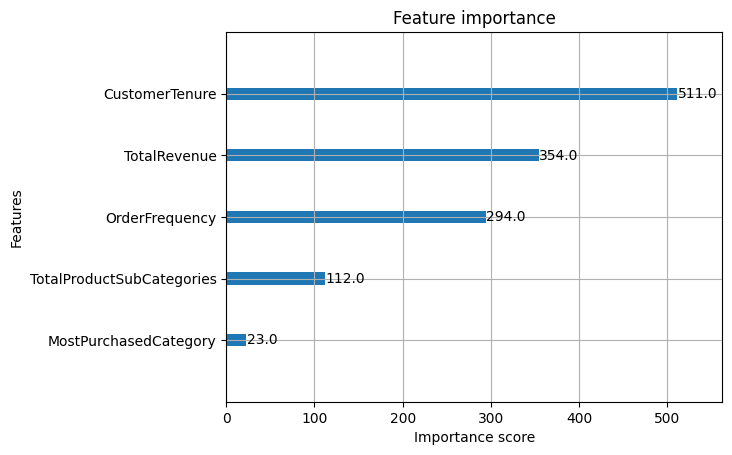

In [ ]:
# Feature importance plot
xgb.plot_importance(model)
plt.show()

In [ ]:
# Permutation feature importance
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(model, X_test, y_test)
perm_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)
perm_importance_df

,Feature,Importance
0,CustomerTenure,0.335900
2,OrderFrequency,0.201506
1,TotalRevenue,0.042845
4,MostPurchasedCategory,0.001255
3,TotalProductSubCategories,-0.002134


In [21]:
# Now save the model using .joblib for future use
import joblib
joblib.dump(model, 'churn_sentinel.joblib')
joblib.dump(0.45, 'decision_boundary.joblib')

['decision_boundary.joblib']

In [22]:
# Load the .joblib model and threshold for future predictions
loaded_model = joblib.load('churn_sentinel.joblib')
loaded_threshold = joblib.load('decision_boundary.joblib')
loaded_model , loaded_threshold

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=250,
               n_jobs=None, num_parallel_tree=None, ...),
 0.45)